In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense, Input, Activation
from tensorflow.keras.optimizers import SGD,Adam
from tensorflow.keras.models import Model,Sequential
from sklearn.model_selection import train_test_split
from tensorflow.keras.datasets import mnist
import pandas as pd

In [2]:
test = pd.read_csv('C:\\Users\\21629\\Documents\\PFA\\mitbih_test.csv\\mitbih_test.csv',header=None)
train = pd.read_csv('C:\\Users\\21629\\Documents\\PFA\\mitbih_train.csv\\mitbih_train.csv',header=None)

In [3]:
print(test.info())
print("********************")
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21892 entries, 0 to 21891
Columns: 188 entries, 0 to 187
dtypes: float64(188)
memory usage: 31.4 MB
None
********************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87554 entries, 0 to 87553
Columns: 188 entries, 0 to 187
dtypes: float64(188)
memory usage: 125.6 MB
None


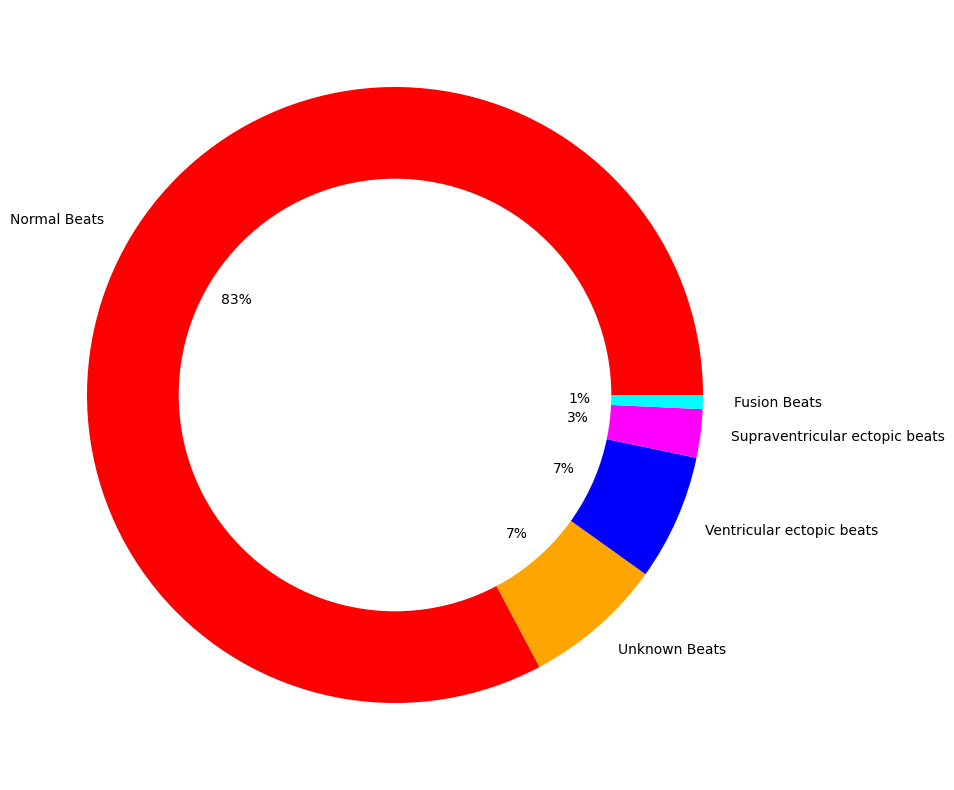

In [4]:
plt.figure(figsize= (10,10))
my_circle = plt.Circle((0,0), 0.7, color = 'white') 
plt.pie(train[187].value_counts(), labels=['Normal Beats','Unknown Beats','Ventricular ectopic beats','Supraventricular ectopic beats',
                                                'Fusion Beats'], autopct = '%0.0f%%', colors = ['red','orange','blue','magenta','cyan'])
p = plt.gcf()
p.gca().add_artist(my_circle)
plt.show()

In [5]:
df_1 = train[train[187] == 1]
df_2 = train[train[187] == 2]
df_3 = train[train[187] == 3]
df_4 = train[train[187] == 4]

In [6]:
from sklearn.utils import resample

df_1_upsample = resample(df_1, n_samples = 20000, replace = True, random_state = 123)
df_2_upsample = resample(df_2, n_samples = 20000, replace = True, random_state = 123)
df_3_upsample = resample(df_3, n_samples = 20000, replace = True, random_state = 123)
df_4_upsample = resample(df_4, n_samples = 20000, replace = True, random_state = 123)
df_0 = train[train[187]==0].sample(n =20000, random_state=123)
train_df = pd.concat([df_0, df_1_upsample, df_2_upsample, df_3_upsample, df_4_upsample])

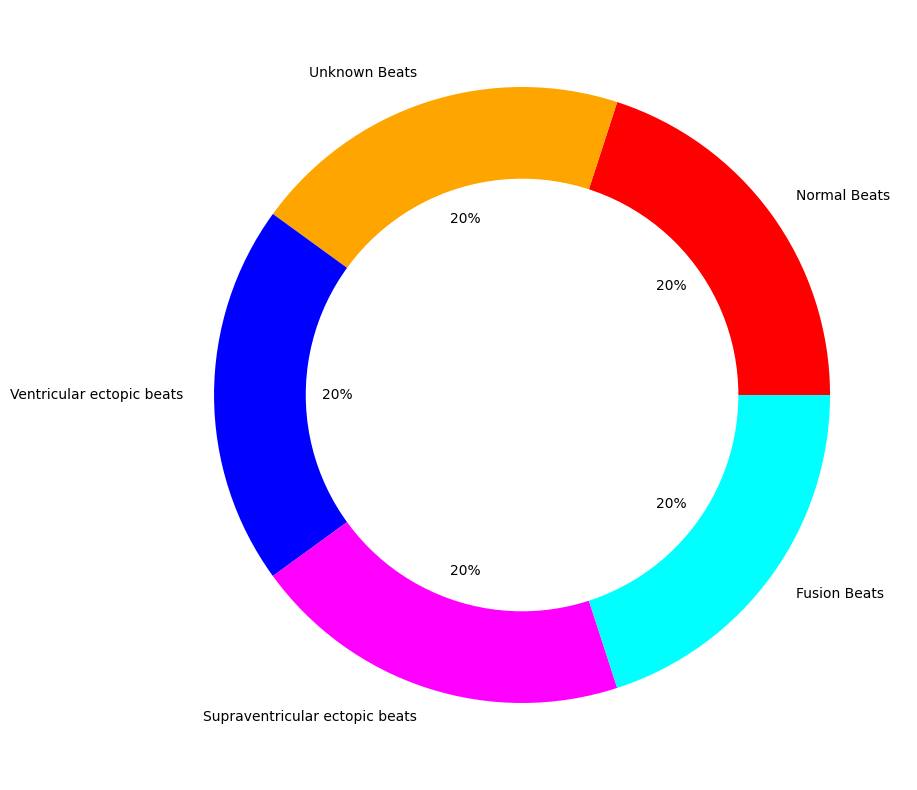

In [7]:
plt.figure(figsize= (10,10))
my_circle = plt.Circle((0,0), 0.7, color = 'white') 
plt.pie(train_df[187].value_counts(), labels=['Normal Beats','Unknown Beats','Ventricular ectopic beats','Supraventricular ectopic beats',
                                                'Fusion Beats'], autopct = '%0.0f%%', colors = ['red','orange','blue','magenta','cyan'])
p = plt.gcf()
p.gca().add_artist(my_circle)
plt.show()

In [8]:
from keras.utils import to_categorical
trainX = train_df.loc[:,train_df.columns!=187]
trainY = train_df.loc[:,train_df.columns==187]
trainY = to_categorical(trainY)
testX = test.loc[:,test.columns!=187]
testY = test.loc[:,test.columns==187]
testY = to_categorical(testY)

In [9]:
print (testX.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21892 entries, 0 to 21891
Columns: 187 entries, 0 to 186
dtypes: float64(187)
memory usage: 31.2 MB
None


In [ ]:
model = Sequential()
model.add(Dense(187,activation='relu' , input_shape=(187,)))
model.add(Dense(100 , activation='relu'))
model.add(Dense(5,activation='softmax'))
model.compile(optimizer='adam',
             loss='categorical_crossentropy',
             metrics=['accuracy'])
his = model.fit(trainX , trainY ,
                batch_size=128,
                validation_data=(testX , testY) ,
                epochs=100 , verbose=True)
print('evaloution: ' )
loss , acc = model.evaluate(testX , testY)
print('loss:' , loss)
print('accuracy: ' , acc)

C:\Users\21629\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7586 - loss: 0.6667 - val_accuracy: 0.8430 - val_loss: 0.4180
Epoch 2/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8940 - loss: 0.2856 - val_accuracy: 0.8352 - val_loss: 0.4475
Epoch 3/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9233 - loss: 0.2159 - val_accuracy: 0.8617 - val_loss: 0.3764
Epoch 4/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9398 - loss: 0.1725 - val_accuracy: 0.8977 - val_loss: 0.2808
Epoch 5/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9498 - loss: 0.1469 - val_accuracy: 0.8892 - val_loss: 0.3225
Epoch 6/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9556 - loss: 0.1287 - val_accuracy: 0.9315 - val_loss: 0.2155
Epoch 7/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9635 - loss: 0.1096 - val_accuracy: 0.9072 - val_loss: 0.2781
Epoch 8/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9683 - loss: 0.0953 - val_accu

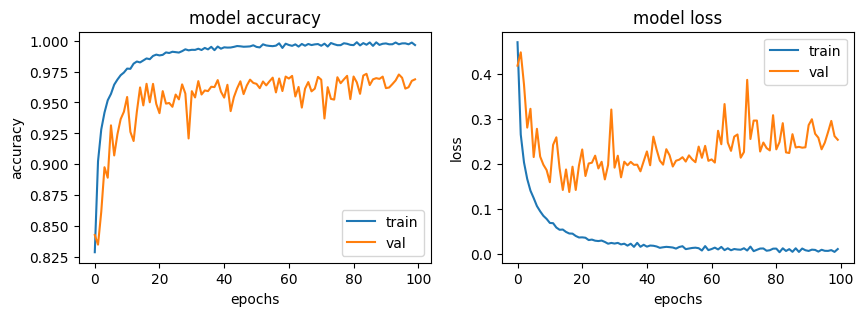

In [12]:
fig , ax= plt.subplots(1,2,figsize=(10,3))
for i, met in enumerate(['accuracy', 'loss']):
    ax[i].plot(his.history[met])
    ax[i].plot(his.history['val_' + met])
    ax[i].set_title('model {}'.format(met))
    ax[i].set_xlabel('epochs')
    ax[i].set_ylabel(met)
    ax[i].legend(['train' , 'val'])
plt.show()

In [13]:
loss, acc = model.evaluate(testX, testY)
print(f'Loss: {loss:.4f}')
print(f'Accuracy: {acc:.4f}')


685/685 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9745 - loss: 0.1570
Loss: 0.2539
Accuracy: 0.9687


In [14]:
y_pred = model.predict(testX)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convertir les probabilités en classes
y_true = np.argmax(testY, axis=1)  # Convertir les one-hot labels en classes réelles


685/685 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


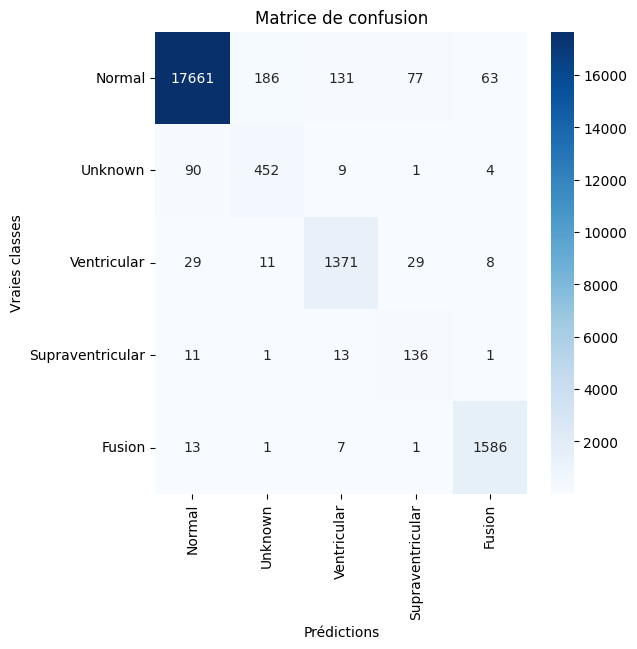

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Normal','Unknown','Ventricular','Supraventricular','Fusion'],
            yticklabels=['Normal','Unknown','Ventricular','Supraventricular','Fusion'])
plt.xlabel("Prédictions")
plt.ylabel("Vraies classes")
plt.title("Matrice de confusion")
plt.show()


In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes, target_names=['Normal','Unknown','Ventricular','Supraventricular','Fusion']))


                  precision    recall  f1-score   support

          Normal       0.99      0.97      0.98     18118
         Unknown       0.69      0.81      0.75       556
     Ventricular       0.90      0.95      0.92      1448
Supraventricular       0.56      0.84      0.67       162
          Fusion       0.95      0.99      0.97      1608

        accuracy                           0.97     21892
       macro avg       0.82      0.91      0.86     21892
    weighted avg       0.97      0.97      0.97     21892



In [19]:
idx = 10  # Choisir un index aléatoire
sample = testX.iloc[idx].values.reshape(1, -1)  # Convertir en numpy array et redimensionner

prediction = model.predict(sample)
predicted_class = np.argmax(prediction)  # Classe prédite

print(f"Classe réelle: {np.argmax(testY[idx])}")
print(f"Classe prédite: {predicted_class}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Classe réelle: 0
Classe prédite: 0


In [20]:
model.save("model_ann_mitbih.h5")

In [21]:
model.save('my_model.keras')